Figure 2: Novel pcQTL discovery. A Normalized shared variance (Methods) explained by PC1 for correlated clusters vs neighboring genes not called as clusters, p-value from two-sample t-test. B Number of pcQTL credible sets vs number of gene clusters across tissues. C Example of credible set groups from a three gene cluster. Nodes are credible sets and edges are colored according to colocalization between the credible sets. D Number of credible set groups of each type across all clusters. E For each credible set group, the minimum credible set lead variant-TSS distance to any gene in the cluster. For credible set groups containing an eQTL credible set, the minimum credible set lead variant-TSS distance to any eGene in the cluster (gene with a significant eQTL credible set in the group). Grey shaded area is | dist | < 250 bp. Inset: Proportion of lead variants with | dist | < 250 bp, p-values from Fisher’s exact test (ns: p>0.05, *: 0.05>p>10-2, **: 10-2p>10-3, ***: 10-3>p>10-4, ***: p<10-4). F The maximum PIP-weighted | log2aFC | for any single gene in the cluster, p-values from two-sample t-test. G The CV of PIP-weighted | log2aFC | across genes in the cluster (quantifying how concentrated vs distributed the effect is), p-values from two-sample t-test.

In [4]:
import sys
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
import seaborn as sns
from scipy.stats import linregress, fisher_exact
from sklearn.decomposition import PCA
from statannotations.Annotator import Annotator
from tqdm.auto import tqdm
import upsetplot as up
import yaml

tqdm.pandas()

# Configuration
prefix = '/home/klawren/oak/pcqtls'
config_path = f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Local imports
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import *
from annotate_null_clusters import *
from get_pcs import *

# Matplotlib configuration
%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [5]:
# load in the pcs
pc_annotated = load_across_tissues(config, load_pc_annotated)
clusters_annotated = load_across_tissues(config, load_clusters_annotated)
cross_map_ids = clusters_annotated[clusters_annotated['has_cross_map']]['cluster_id']

# varaince for clusters
cluster_summed_var = []
for n_genes, pc_annotated_group in pc_annotated[(pc_annotated['pc_id']==1)].groupby("cluster_size"):
    cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
cluster_summed_var = np.asarray([item for sublist in cluster_summed_var for item in sublist])

/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/883511723.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/883511723.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cluster_summed_var.append((pc_annotated_group.groupby(["cluster_id", "tissue_id", "pc_id", "cluster_size"])['egene_r2'].agg(sum) - 1)/(n_genes-1))
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/883511723.py:9: FutureWarning: The provi

In [6]:
# Load GENCODE annotations
print("Loading GENCODE annotations...")
gid_gencode = pd.read_table(f"{config['working_dir']}/{config["gencode_path"]}").set_index('gene_id')
gid_gencode['tss_pos'] = gid_gencode['tss_pos'].apply(literal_eval)
print(f"Loaded {len(gid_gencode)} genes from GENCODE")

Loading GENCODE annotations...
Loaded 19817 genes from GENCODE


In [7]:
tissue_id = 'Cells_Cultured_fibroblasts'
num_genes = 2 
expression_path = f'{config["working_dir"]}/{config["expression_dir"]}{tissue_id}.v8.normalized_expression.bed'
real_clusters_path = f'{config["working_dir"]}/{config["clusters_dir"]}/{tissue_id}.clusters.txt'
covariates_path = f'{config["working_dir"]}/{config["covariates_dir"]}/{tissue_id}.v8.covariates.txt'


expressed_genes = load_expressed_genes(expression_path)
real_clusters = pd.read_table(real_clusters_path)

expression_df = pd.read_table(expression_path)
sample_ids = expression_df.columns[4:]
expression_df_gid = expression_df.set_index('gene_id')
covariates_df = pd.read_table(covariates_path, index_col=0).T

residualized_expression = calculate_residual(expression_df[expression_df.columns[4:]], covariates_df, center=True)
residualized_expression = pd.DataFrame(residualized_expression, columns=expression_df.columns[4:], index=expression_df['gene_id'].values)

null_clusters = get_null_clusters(expressed_genes, num_genes, real_clusters)

# Generate PCs for each null cluster and calculate normalized R²
genome_summed_var = []

for idx, row in tqdm(null_clusters.iterrows(), total=len(null_clusters)):
    cluster_id = row['cluster_id']
    
    # Split cluster_id to get individual gene IDs
    gene_ids = cluster_id.split('_')
    
    # Extract expression data for genes in this null cluster
    cluster = residualized_expression.loc[gene_ids]
    
    # Perform PCA on cluster expression data
    X = cluster[sample_ids].transpose()
    pca = PCA()
    pc_values = pca.fit_transform(X)
    
    # Calculate egene R² for each PC and normalize by cluster size
    n_genes = len(cluster)
    pc_num=0
    # Calculate R² between PC and each egene in the cluster
    egene_r2_values = []
    for egene_id in gene_ids:
        egene_expression = cluster.loc[egene_id, sample_ids].to_numpy(dtype=float)
        pc_expression = pc_values[:, pc_num]
        
        # Calculate R²
        slope, intercept, r_value, p_value, std_err = linregress(pc_expression, egene_expression)
        r2 = r_value ** 2
        egene_r2_values.append(r2)
    
    # Sum R² values and normalize by cluster size
    summed_r2 = (sum(egene_r2_values) - 1) / (n_genes - 1)
    
    genome_summed_var.append(summed_r2)

print(f"Generated {len(genome_summed_var)} normalized R² values for null clusters")
genome_summed_var = np.asarray(genome_summed_var)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13454/13454 [00:53<00:00, 250.06it/s]

Generated 13454 normalized R² values for null clusters


In [8]:
susie = load_across_tissues(config, load_susie)
susie['type'] = np.where(susie['phenotype_id'].str.contains('_pc'), 'pcqtl', 'eqtl')
susie['cs_id'] = susie['phenotype_id'] + '_cs_' + susie['cs_id'].astype(str)

clusters = load_across_tissues(config, load_cluster)
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)

pcqtl_cs_counts = susie[susie['type'] == 'pcqtl'].groupby(['tissue_id']).agg({'cs_id':'nunique'})
cluster_counts = clusters.groupby('tissue_id').agg({'cluster_id':'nunique'})
cs_counts = pd.merge(cluster_counts, pcqtl_cs_counts, on='tissue_id').reset_index()

In [30]:
pair_coloc = load_across_tissues(config, load_pairwise_coloc)
pair_coloc['cluster_id'] = pair_coloc['qtl1_id'].str.split('_pc').str[0].str.split('_e_').str[0]

qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['pcQTL'] = qtl_signal_groups['num_pc_coloc'] > 0
qtl_signal_groups['eQTL'] = qtl_signal_groups['num_e_coloc'] > 0
qtl_signal_groups['exclusive_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

In [11]:
# add tss distance

# Load SuSiE credible sets for eQTLs and pcQTLs
print("Loading SuSiE credible sets...")
eqtl_susie = load_across_tissues(config, load_e_susie)
pcqtl_susie = load_across_tissues(config, load_pc_susie)

print(f"Loaded {len(eqtl_susie)} eQTL credible set variants")
print(f"Loaded {len(pcqtl_susie)} pcQTL credible set variants")

# Function to extract lead variant (max PIP) for each credible set
def get_lead_variants(susie_df):
    # Group by phenotype_id and cs_id, find max PIP
    lead_variants = susie_df.loc[susie_df.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['pip'].idxmax()].copy()
    lead_variants['cluster_id'] = lead_variants['phenotype_id'].str.split('_e_').str[0].str.split('_pc').str[0]
    lead_variants['variant_pos'] = lead_variants['variant_id'].str.split('_').str[1].astype(int)
    return lead_variants

# Extract lead variants
eqtl_leads = get_lead_variants(eqtl_susie)
pcqtl_leads = get_lead_variants(pcqtl_susie)

print(f"Found {len(eqtl_leads)} eQTL lead variants")
print(f"Found {len(pcqtl_leads)} pcQTL lead variants")

eqtl_leads = eqtl_leads.drop_duplicates(subset=['variant_id'])
pcqtl_leads = pcqtl_leads.drop_duplicates(subset=['variant_id'])

print(f"Found {len(eqtl_leads)} unique eQTL lead variants")
print(f"Found {len(pcqtl_leads)} unique pcQTL lead variants")

def get_tss_distribution(qtl_leads, match_egene=False, group_signal_id=True, rolling_window=1000):
        qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')

        # add in gene tss information
        qtl_leads_exploded = pd.merge(qtl_leads.explode('gene_id'), gid_gencode.explode('tss_pos'), left_on='gene_id', right_on='gene_id', how='left')
        # annotate distance (positive or negative based on strand)
        qtl_leads_exploded['tss_dist'] = np.where(qtl_leads_exploded['strand'] == '+', 
                qtl_leads_exploded['tss_pos'] - qtl_leads_exploded['variant_pos'], 
                qtl_leads_exploded['variant_pos'] - qtl_leads_exploded['tss_pos'])

        qtl_leads_exploded = pd.merge(qtl_leads_exploded, qtl_signals_groups_exploded, on = ['qtl_cs_id', 'tissue_id'], how = 'left')
 
        if match_egene:
                qtl_leads_exploded['egene_id'] = qtl_leads_exploded['phenotype_id'].str.split('_e_').str[1]
                qtl_leads_exploded_egene_matched = qtl_leads_exploded[qtl_leads_exploded['egene_id'] == qtl_leads_exploded['gene_id']]

                # get the closest tss distance for the egene for each credible set
                if group_signal_id:
                        qtl_min_distance = qtl_leads_exploded_egene_matched.groupby(['tissue_id', 'signal_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
                else:
                        qtl_min_distance = qtl_leads_exploded_egene_matched.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
        else:
                # get the closest tss distance for each credible set
                if group_signal_id:
                        qtl_min_distance = qtl_leads_exploded.groupby(['tissue_id', 'signal_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
                else:
                        qtl_min_distance = qtl_leads_exploded.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['tss_dist'].apply(lambda x: x.iloc[np.argmin(abs(x))])
        qtl_counts, dist_bin_edges = np.histogram(qtl_min_distance, bins=np.arange(qtl_min_distance.min(), qtl_min_distance.max(), 1))
        qtl_counts = pd.DataFrame({'qtl_counts':qtl_counts, 'tss_distance':dist_bin_edges[:-1]})
        qtl_counts['rolling_qtl_density'] = qtl_counts['qtl_counts'].rolling(rolling_window).mean()/qtl_counts['qtl_counts'].sum()
        qtl_counts['adjusted_tss_distance'] = qtl_counts['tss_distance'] - (rolling_window/2)

        return qtl_counts, qtl_min_distance


Loading SuSiE credible sets...
Loaded 455306 eQTL credible set variants
Loaded 443922 pcQTL credible set variants
Found 19166 eQTL lead variants
Found 18149 pcQTL lead variants
Found 13758 unique eQTL lead variants
Found 13457 unique pcQTL lead variants


In [31]:
# add in pcqtl that are not found as eqtl

rolling_window = 100
qtl_signal_groups['qtl_cs_id'] = qtl_signal_groups['signal_id'].str.split('-')
qtl_signals_groups_exploded = qtl_signal_groups.explode('qtl_cs_id')

# leads from "pcQTL only" credible set groups to closest cluster gene
pcqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_e_coloc'] == 0]
pcqtl_leads['qtl_cs_id'] = pcqtl_leads['phenotype_id'] + '_cs_' + pcqtl_leads['cs_id'].astype(str)
pcqtl_only_leads = pcqtl_leads[pcqtl_leads['qtl_cs_id'].isin(pcqtl_only_signal_groups['qtl_cs_id'])]
pcqtl_only_counts, pcqtl_only_min_dist = get_tss_distribution(pcqtl_only_leads, match_egene=False, rolling_window=rolling_window)

# leads from "eQTL only" credible set groups to closest cluster gene
eqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_pc_coloc'] == 0]
eqtl_leads['qtl_cs_id'] = eqtl_leads['phenotype_id'] + '_cs_' + eqtl_leads['cs_id'].astype(str)
eqtl_only_leads = eqtl_leads[eqtl_leads['qtl_cs_id'].isin(eqtl_only_signal_groups['qtl_cs_id'])]
eqtl_only_counts, eqtl_only_min_dist = get_tss_distribution(eqtl_only_leads, match_egene=False, rolling_window=rolling_window)
eqtl_matched_counts, eqtl_matched_min_dist = get_tss_distribution(eqtl_only_leads, match_egene=True, rolling_window=rolling_window)

# leads from "both" credible set groups to closest cluster gene
both_signal_groups = qtl_signals_groups_exploded[(qtl_signals_groups_exploded['num_e_coloc'] > 0) & (qtl_signals_groups_exploded['num_pc_coloc'] > 0)]
both_leads = pd.concat([pcqtl_leads[pcqtl_leads['qtl_cs_id'].isin(both_signal_groups['qtl_cs_id'])], eqtl_leads[eqtl_leads['qtl_cs_id'].isin(both_signal_groups['qtl_cs_id'])]])
both_counts, both_min_dist = get_tss_distribution(both_leads, match_egene=False, rolling_window=rolling_window)
both_matched_counts, both_matched_min_dist = get_tss_distribution(both_leads, match_egene=True, rolling_window=rolling_window)

/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/2066486255.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/2066486255.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qtl_leads['gene_id'] = qtl_leads['cluster_id'].str.split('_')
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/2066486255.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [32]:
# p values for the distance bar plot
cutoff = 250

# Build abs distance arrays and palettes with clear names
distance_group_labels = [
    "pcQTL only\n(any)",
    "eQTL only\n(any)",
    "both\n(any)",
    "eQTL\n(eGene)",
    "both\n(eGene)"
]

distance_group_to_values = {
    "pcQTL only\n(any)": np.abs(pcqtl_only_min_dist),
    "eQTL only\n(any)": np.abs(eqtl_only_min_dist),
    "both\n(any)": np.abs(both_min_dist),
    "eQTL\n(eGene)": np.abs(eqtl_matched_min_dist),
    "both\n(eGene)": np.abs(both_matched_min_dist)
}

distance_palette = {
    "pcQTL only\n(any)": qtl_colors['pcQTL'],
    "eQTL only\n(any)": qtl_colors['eQTL'],
    "both\n(any)": qtl_palette['Both'],
    "eQTL\n(eGene)": qtl_colors['eQTL'],
    "both\n(eGene)": qtl_palette['Both']
}

# Build a flat dataframe for all points, with more explicit names
distance_bar_df = pd.concat([
    pd.DataFrame({
        "distance_group_label": label,
        "abs_distance": np.asarray(distance_group_to_values[label]),
        "below_cutoff": np.asarray(distance_group_to_values[label]) <= cutoff
    })
    for label in distance_group_labels
], ignore_index=True)

# Calculate fractions, counts, totals and labels explicitly
distance_bar_fractions = (
    distance_bar_df.groupby("distance_group_label")["below_cutoff"]
    .mean().reindex(distance_group_labels).values * 100
)
distance_bar_counts = (
    distance_bar_df.groupby("distance_group_label")["below_cutoff"]
    .sum().reindex(distance_group_labels).astype(int).values
)
distance_bar_totals = (
    distance_bar_df.groupby("distance_group_label")["below_cutoff"]
    .count().reindex(distance_group_labels).astype(int).values
)
distance_bar_fraction_labels = [
    f"{c}/{t}" for c, t in zip(distance_bar_counts, distance_bar_totals)
]

# Fisher exact tests for every group pair
distance_bar_pairs = list(combinations(distance_group_labels, 2))
distance_bar_custom_pvalues = []
for label1, label2 in distance_bar_pairs:
    vals1 = np.asarray(distance_group_to_values[label1])
    vals2 = np.asarray(distance_group_to_values[label2])
    count1_above = np.sum(vals1 > cutoff)
    count2_above = np.sum(vals2 > cutoff)
    count1_below = len(vals1) - count1_above
    count2_below = len(vals2) - count2_above
    contingency = np.array([[count1_above, count1_below], [count2_above, count2_below]])
    _, p = fisher_exact(contingency)
    distance_bar_custom_pvalues.append(p)

In [33]:
pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')

eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')

susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()
susie_explode = susie.explode('gene_id')

In [34]:
# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()


# group over genes in a cluster that a credible set impacts
cluster_grouped_afc = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std'), 
    max_afc=('abs_pip_afc_weighted', 'max')).reset_index()

cluster_grouped_afc['cv_afc'] =  cluster_grouped_afc['std_afc'] / cluster_grouped_afc['mean_afc'] * 100

# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
cluster_grouped_afc['cs_phenotype_id'] = cluster_grouped_afc['phenotype_id'] + '_cs_' + cluster_grouped_afc['cs_id'].astype(str)
cluster_grouped_afc = pd.merge(cluster_grouped_afc, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')
cluster_grouped_afc['qtl_group_label'] = np.where((cluster_grouped_afc['num_e_coloc'] > 0), np.where((cluster_grouped_afc['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

# add pc order information 
cluster_grouped_afc['pc_num'] = np.where(cluster_grouped_afc['phenotype_id'].str.contains('_pc'), cluster_grouped_afc['phenotype_id'].str.split('_pc').str[-1], 0).astype(int)
cluster_grouped_afc['num_genes'] = cluster_grouped_afc['cluster_id'].str.split('_').apply(len)
cluster_grouped_afc['pc_order'] = np.where(cluster_grouped_afc['pc_num']==0, 'eqtl', 
            np.where(cluster_grouped_afc['pc_num'] == 1, 'first',
            np.where(cluster_grouped_afc['pc_num'] == cluster_grouped_afc['num_genes'], 'last', 'middle')))

primary_pc_afc = cluster_grouped_afc[cluster_grouped_afc['pc_order'].isin(['eqtl', 'first'])]
primary_pc_afc.groupby('qtl_group_label').agg(median_max_afc=('max_afc', 'median'), median_cv_afc=('cv_afc', 'median')).reset_index()

,qtl_group_label,median_max_afc,median_cv_afc
0,Both,0.868736,51.058344
1,eQTL only,0.625643,57.735381
2,pcQTL only,0.595346,46.353257


In [35]:
cluster_id = 'ENSG00000099974.7_ENSG00000133433.10_ENSG00000240972.1'
tissue_id = 'Adipose_Subcutaneous'


def get_gene_name(gene_id):
    try:
        return gid_gencode.loc[gene_id]['gene_name']
    except KeyError:
        return gene_id

cluster_pairs = pair_coloc[(pair_coloc['cluster_id'] == cluster_id) & (pair_coloc['tissue_id'] == tissue_id)]
cluster_pairs['qtl1_id_short'] = np.where(cluster_pairs['qtl1_id'].str.contains('_e_'), cluster_pairs['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs['qtl2_id_short'] = np.where(cluster_pairs['qtl2_id'].str.contains('_e_'), cluster_pairs['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs['qtl1_id_short'] = cluster_pairs['qtl1_id_short'].apply(get_gene_name) + '-cs' + cluster_pairs['idx1'].astype(str)
cluster_pairs['qtl2_id_short'] = cluster_pairs['qtl2_id_short'].apply(get_gene_name)+ '-cs' + cluster_pairs['idx2'].astype(str)


/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/2182780878.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_pairs['qtl1_id_short'] = np.where(cluster_pairs['qtl1_id'].str.contains('_e_'), cluster_pairs['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs['qtl1_id'].str.split('_pc').str[-1])
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/2182780878.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_pairs['qtl2_id_short'] = np.where(cluster_pairs['qtl2_id'].str.cont

/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(['correlated', 'uncorrelated'], ha='center')
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(
/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

Both, eQTL only p=1.97e-203
Both, pcQTL only p=1.46e-98
eQTL only, pcQTL only p=1.40e-03


/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_e.set_xticklabels([qtl_group_display_labels.get(lbl.get_text(), lbl.get_text()) for lbl in ax_e.get_xticklabels()])


Both, eQTL only p=5.94e-19
Both, pcQTL only p=1.86e-05
eQTL only, pcQTL only p=3.59e-18


/local/scratch/klawren/slrmtmp.49579061/ipykernel_14883/1226229800.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_f.set_xticklabels([qtl_group_display_labels.get(lbl.get_text(), lbl.get_text()) for lbl in ax_f.get_xticklabels()])


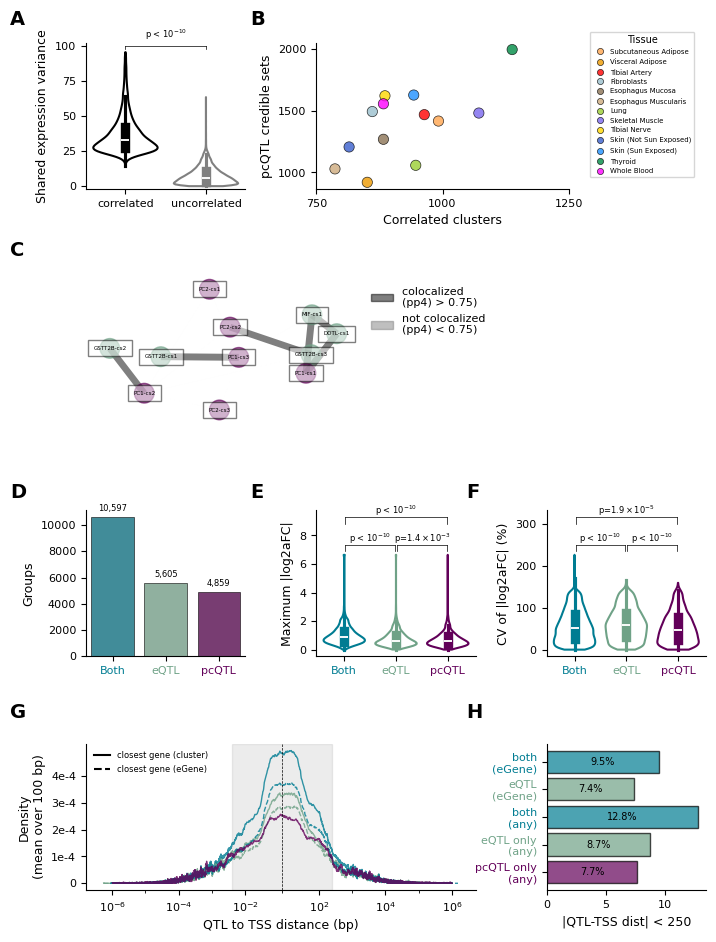

In [85]:
fig = plt.figure(figsize=(8, 11))

gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    hspace=0.6, wspace=1.6,
    width_ratios=[1, 1, 1, 1, .5, 1.5],
    height_ratios=[1, 1, 1, 1]
)

ax_a = fig.add_subplot(gs[0, 0:2])
ax_b = fig.add_subplot(gs[0, 2:5])
ax_b_legend = fig.add_subplot(gs[0, 5:6])
ax_c = fig.add_subplot(gs[1, 0:3])
ax_d = fig.add_subplot(gs[2, 0:2])
ax_e = fig.add_subplot(gs[2, 2:4])
ax_f = fig.add_subplot(gs[2, 4:6])
ax_g = fig.add_subplot(gs[3, :4])
ax_g_inset = fig.add_subplot(gs[3, 4:6])

# --- PANEL A ---
df_violin = pd.DataFrame({
    "value": np.concatenate([cluster_summed_var, genome_summed_var]),
    "group": ["Clusters"] * len(cluster_summed_var) + ["Non-cluster pairs"] * len(genome_summed_var)
})
sns.violinplot(
    data=df_violin, x="group", y="value",
    ax=ax_a, palette=['k', 'grey'], fill=False, cut=0
)
ax_a.set_ylim((-.02, 1.02))
ax_a.set_yticks([0, .25, .50, .75, 1])
ax_a.set_yticklabels([0, 25, 50, 75, 100])
ax_a.set_ylabel("Shared expression variance")
ax_a.set_xlabel('')
ax_a.spines[['right', 'top']].set_visible(False)
ax_a.set_xticklabels(['correlated', 'uncorrelated'], ha='center')
y_max = ax_a.get_ylim()[1]
x1, x2 = 0, 1
y = y_max * 0.98
h = 0.02 * (y_max)
ax_a.plot([x1, x2], [y, y], lw=.5, c='black', zorder=10)
ax_a.plot([x1, x1], [y, y-h], lw=.5, c='black', zorder=10)
ax_a.plot([x2, x2], [y, y-h], lw=.5, c='black', zorder=10)
ax_a.text((x1+x2)/2, y+h*1.3, "p < 10$^{-10}$", ha='center', va='bottom', color='black', fontsize=6)

# --- PANEL B ---
sns.scatterplot(
    cs_counts, y='cs_id', x='cluster_id', hue='tissue_id',
    palette=gtex_tissue_pal, ax=ax_b, s=55, alpha=.8, legend=True, edgecolor='k', linewidth=0.5
)
ax_b.set_xlabel('Correlated clusters')
ax_b.set_ylabel('pcQTL credible sets')
ax_b.set_yticks([1000, 1500, 2000])
ax_b.set_xticks([750, 1000, 1250])
ax_b.spines[['top', 'right']].set_visible(False)
legend = ax_b.get_legend()
if legend is not None:
    legend.remove()
ax_b_legend.axis('off')
legend_handles, legend_labels = ax_b.get_legend_handles_labels()
if legend_labels and legend_labels[0].lower() == 'tissue_id':
    legend_handles = legend_handles[1:]
    legend_labels = legend_labels[1:]
legend_labels = [lbl.replace("Skin_Not_Sun_Exposed_Suprapubic", "Skin (Not Sun Exposed)")
                    .replace("Skin_Sun_Exposed_Lower_leg", "Skin (Sun Exposed)")
                    .replace("Cells_Cultured_fibroblasts", "Fibroblasts")
                    .replace("Adipose_Subcutaneous", "Subcutaneous Adipose")
                    .replace("Adipose_Visceral_Omentum", "Visceral Adipose")
                    .replace("Muscle_Skeletal", "Skeletal Muscle")
                    .replace("Nerve_Tibial", "Tibial Nerve")
                    .replace("Artery_Tibial", "Tibial Artery")
                for lbl in legend_labels]
legend_labels = [lbl.replace('_', ' ') for lbl in legend_labels]
ax_b_legend.legend(
    legend_handles, legend_labels,
    title="Tissue", frameon=True, fontsize=5, loc="upper left",
    title_fontsize=7, labelspacing=0.5, handletextpad=0.5, bbox_to_anchor=(-.8, 1.1),
    markerscale=0.6
)

# --- PANEL C ---
G = nx.Graph()
for index, row in cluster_pairs.iterrows():
    G.add_edge(row['qtl1_id_short'], row['qtl2_id_short'], weight=row['PP.H4.abf'])
edge_weights = [G[u][v]['weight']*5 for u, v in G.edges()]
edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['eQTL only'] if not 'PC' in node else qtl_palette['pcQTL only'] for node in G.nodes()]
pos = nx.spring_layout(G, k=1.5)
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, alpha=0.6, ax=ax_c)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.5, ax=ax_c)
nx.draw_networkx_labels(G, pos, ax=ax_c, font_size=4, bbox=dict(facecolor='white', alpha=0.5, edgecolor='k'))
purple_patch = mpatches.Patch(color='k', alpha=0.5, label='colocalized \n(pp4) > 0.75)')
gray_patch = mpatches.Patch(color='gray', alpha=0.5, label='not colocalized \n(pp4) < 0.75)')
ax_c.legend(handles=[purple_patch, gray_patch], loc='upper right', frameon=False)
sns.move_legend(ax_c, "upper left", bbox_to_anchor=(1, 1))
sns.despine(ax=ax_c, left=True, bottom=True)

# --- PANEL D ---
qtl_group_display_labels = {
    "Both": "Both",
    "eQTL only": "eQTL",
    "pcQTL only": "pcQTL"
}
display_order = [qtl_group_display_labels[o] for o in ['Both', 'eQTL only', 'pcQTL only']]
bars = sns.countplot(
    data=qtl_signal_groups,
    x='exclusive_label',
    order=['Both', 'eQTL only', 'pcQTL only'],
    palette=qtl_palette,
    edgecolor='k',
    linewidth=.5,
    ax=ax_d, 
    alpha=.8
)
ax_d.set_ylabel("Groups")
ax_d.set_xlabel("")
ax_d.spines[['right', 'top']].set_visible(False)
ax_d.set_xticklabels([qtl_group_display_labels.get(lbl.get_text(), lbl.get_text()) for lbl in ax_d.get_xticklabels()])
for i, tick_label in enumerate(ax_d.get_xticklabels()):
    group_name = tick_label.get_text()
    orig_group = [k for k, v in qtl_group_display_labels.items() if v == group_name]
    orig_group = orig_group[0] if orig_group else group_name
    if orig_group in qtl_palette:
        tick_label.set_color(qtl_palette[orig_group])
for p in bars.patches:
    if p is not None:
        height = p.get_height()
        if np.isfinite(height):
            formatted_height = "{:,}".format(int(height))
            ax_d.annotate(
                formatted_height,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=6,
                xytext=(0, 3),
                textcoords='offset points'
            )

# --- PANEL E ---
sns.violinplot(
    data=primary_pc_afc, x='qtl_group_label', y='max_afc',
    hue='qtl_group_label', palette=qtl_palette, ax=ax_e, cut=0,
    inner='box', linewidth=1.5, saturation=0.8, fill=False
)
ax_e.spines[['right', 'top']].set_visible(False)
ax_e.set_ylabel('Maximum |log2aFC|')
ax_e.set_yticks([0, 2, 4, 6, 8])
add_statistical_significance(ax_e, primary_pc_afc, 'qtl_group_label', 'max_afc', pvalue_style="pval")
ax_e.set_xlabel('')
ax_e.set_xticklabels([qtl_group_display_labels.get(lbl.get_text(), lbl.get_text()) for lbl in ax_e.get_xticklabels()])
for i, tick_label in enumerate(ax_e.get_xticklabels()):
    group_name = tick_label.get_text()
    orig_group = [k for k, v in qtl_group_display_labels.items() if v == group_name]
    orig_group = orig_group[0] if orig_group else group_name
    if orig_group in qtl_palette:
        tick_label.set_color(qtl_palette[orig_group])

# --- PANEL F ---
sns.violinplot(
    data=primary_pc_afc, x='qtl_group_label', y='cv_afc',
    hue='qtl_group_label', palette=qtl_palette, ax=ax_f, cut=0,
    inner='box', linewidth=1.5, saturation=0.8, fill=False
)
ax_f.spines[['right', 'top']].set_visible(False)
ax_f.set_ylabel('CV of |log2aFC| (%)')
ax_f.set_xlabel('')
ax_f.set_yticks([0, 100, 200, 300])
add_statistical_significance(ax_f, primary_pc_afc, 'qtl_group_label', 'cv_afc', pvalue_style="pval")
ax_f.set_xticklabels([qtl_group_display_labels.get(lbl.get_text(), lbl.get_text()) for lbl in ax_f.get_xticklabels()])
for i, tick_label in enumerate(ax_f.get_xticklabels()):
    group_name = tick_label.get_text()
    orig_group = [k for k, v in qtl_group_display_labels.items() if v == group_name]
    orig_group = orig_group[0] if orig_group else group_name
    if orig_group in qtl_palette:
        tick_label.set_color(qtl_palette[orig_group])

# --- PANEL G ---
line_eqtl = sns.lineplot(
    x='adjusted_tss_distance', y='rolling_qtl_density', data=eqtl_only_counts, 
    color=qtl_colors['eQTL'], ax=ax_g, alpha=.8, linewidth=1
)
line_both = sns.lineplot(
    x='adjusted_tss_distance', y='rolling_qtl_density', data=both_counts, 
    color=qtl_palette['Both'], ax=ax_g, alpha=.8, linewidth=1
)
line_eqtl_matched = sns.lineplot(
    x='adjusted_tss_distance', y='rolling_qtl_density', data=eqtl_matched_counts, 
    color=qtl_colors['eQTL'], ax=ax_g, alpha=.8, ls='--', linewidth=1
)
line_both_matched = sns.lineplot(
    x='adjusted_tss_distance', y='rolling_qtl_density', data=both_matched_counts, 
    color=qtl_palette['Both'], ax=ax_g, alpha=.8, ls='--', linewidth=1
)
line_pcqtl = sns.lineplot(
    x='adjusted_tss_distance', y='rolling_qtl_density', data=pcqtl_only_counts, 
    color=qtl_colors['pcQTL'], ax=ax_g, alpha=.8, linewidth=1, 
)
ax_g.set_xscale('symlog', linthresh=rolling_window)
ax_g.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
ax_g.set_xlabel('QTL to TSS distance (bp)')
ax_g.set_ylabel('Density\n(mean over 100 bp)')
ax_g.spines[['top', 'right']].set_visible(False)
ax_g.axvspan(-cutoff, cutoff, color='grey', alpha=0.15)
ax_g.set_xticks([-1e6, -1e4, -1e2, 1e2, 1e4, 1e6])
ax_g.set_xticklabels([r"$10^{-6}$", r"$10^{-4}$", r"$10^{-2}$", r"$10^{2}$", r"$10^{4}$", r"$10^{6}$"])
ax_g.set_yticks([0, 0.0001, 0.0002, 0.0003, 0.0004])
ax_g.set_yticklabels(['0', '1e-4', '2e-4', '3e-4', '4e-4'])
custom_lines = [
    Line2D([0], [0], color='black', linestyle='-', lw=1.5, label="closest gene (cluster)"),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label="closest gene (eGene)")
]
ax_g.legend(handles=custom_lines, loc='upper left', fontsize=6, frameon=False)

# --- PANEL G INSET ---
bars = ax_g_inset.barh(
    np.arange(len(distance_group_labels)), distance_bar_fractions,
    color=[distance_palette[g] for g in distance_group_labels],
    alpha=0.7,
    edgecolor='black'
)
ax_g_inset.spines[['top', 'right']].set_visible(False)
ax_g_inset.set_yticks(np.arange(len(distance_group_labels)))
ax_g_inset.set_yticklabels(distance_group_labels, fontsize=8)
for label, color in zip(ax_g_inset.get_yticklabels(), [distance_palette[g] for g in distance_group_labels]):
    label.set_color(color)
for rect, val in zip(bars, distance_bar_fractions):
    if rect is not None:
        width = rect.get_width()
        ax_g_inset.annotate(
            '{:.1f}%'.format(val),
            xy=(width / 2, rect.get_y() + rect.get_height() / 2),
            ha='center', va='center',
            fontsize=7, color='black', rotation=0
        )

ax_g_inset.set_aspect(aspect='auto', adjustable='box')
ax_g_inset.tick_params(axis='both', which='major', labelsize=8)
ax_g_inset.grid(False)
ax_g_inset.set_xlabel('|QTL-TSS dist| < 250')
annotator = Annotator(
    ax_g_inset, 
    distance_bar_pairs, 
    data=distance_bar_df, 
    x="below_cutoff", 
    y="distance_group_label", 
    order=distance_group_labels,
    orient='h'
)
annotator.configure(
    test=None,
    test_short_name="",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction=None,
    line_height=.05,
    text_offset=0,
    line_offset=-1,
    line_offset_to_group=-1,
    line_width=1,
    fontsize=6
)
annotator.set_pvalues(distance_bar_custom_pvalues)

x_left = 0.03
x_middle = .33
x_right = 0.6 
y_1 = 0.91
y_2 = 0.7
y_3 = 0.48
y_4 = 0.28

fig.text(x_left,  y_1,    'A', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_middle, y_1,    'B', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_left,  y_2, 'C', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_left,  y_3, 'D', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_middle,  y_3, 'E', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_right,  y_3, 'F', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_left,  y_4, 'G', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_right, y_4, 'H', fontsize=14, fontweight='bold', ha='left', va='top')

plt.savefig(f"{config['working_dir']}/workflow/main_figures/figures/figure_2_combined.pdf",
            transparent=True, bbox_inches='tight', dpi=300)

plt.show()